# Hyperparameter Tuning

---

**Dataset:** [Nombre del dataset]

---

## ¿Que es el Hyperparameter Tuning y por que lo hacemos?

### La analogia del chef

Imagina que eres un chef y tienes una receta de pasta. La receta base dice:
cocinar **10 minutos**, agregar **1 cucharada de sal**, fuego **medio**.
Esa receta funciona, pero no necesariamente es la mejor version posible
para **tu cocina, tu estufa y tus ingredientes especificos**.

El Hyperparameter Tuning es exactamente eso:
> **Ajustar los parametros de la receta hasta encontrar la combinacion
> que produce el mejor resultado con TUS datos especificos.**

En Machine Learning:

| Analogia del chef | En Machine Learning |
|---|---|
| La receta | El algoritmo (RandomForest, GradientBoosting...) |
| Los ingredientes | Tu dataset |
| Los tiempos y cantidades | Los **hiperparametros** |
| El mejor plato | El modelo con mayor ROC-AUC o R2 |

---

### ¿Por que los valores por defecto no son suficientes?

Cuando escribes `RandomForestClassifier()` sin especificar nada, sklearn usa
valores por defecto diseñados para funcionar **razonablemente bien** en la mayoria
de datasets. Pero tu dataset tiene caracteristicas unicas: cierto numero de filas,
cierto nivel de ruido, cierto balance de clases.

```python
# Lo que has estado usando hasta ahora
RandomForestClassifier(n_estimators=100)   # default de sklearn

# Lo que podrias descubrir con tuning
RandomForestClassifier(n_estimators=250, max_depth=15, min_samples_leaf=3)
```

La diferencia entre defaults y tuning puede ser la diferencia entre
un **ROC-AUC de 0.82 y uno de 0.89**. En un proyecto real eso es enorme.

---

### ¿Que es un hiperparametro? — con ejemplos reales

Piensa en un hiperparametro como una **perilla de control** del modelo.
No es algo que el modelo aprende de los datos: es algo que **TU defines** antes de entrenar.

| Hiperparametro | Analogia | Que controla |
|---|---|---|
| `n_estimators` | Cuantos jueces votan en un jurado | Numero de arboles del bosque |
| `max_depth` | Cuantos niveles tiene un organigrama | Profundidad maxima de cada arbol |
| `learning_rate` | El zoom de un microscopio | Que tan grandes son los pasos del aprendizaje |
| `C` en LogReg | Que tan literal eres con las instrucciones | Fuerza de la regularizacion |

---

### La estrategia de dos fases — por que no probamos todo

Si tienes 5 hiperparametros con 10 valores cada uno, hay **10^5 = 100,000 combinaciones**.
Probarlas todas con CV de 5 folds = **500,000 entrenamientos**. Eso puede tardar dias.

La solucion es una estrategia de dos fases:

```
Fase 1 — RandomizedSearch : rango amplio, exploracion rapida
  Como buscar tu llave revisando todas las habitaciones sin abrir cada cajon.
  Resultado: 'la llave esta en el dormitorio'

Fase 2 — GridSearch       : rango estrecho, busqueda exhaustiva
  Ahora que sabes la habitacion, revisas cada cajon de ese cuarto.
  Resultado: 'la llave esta en el segundo cajon de la mesita de noche'
```

---

### El mensaje mas importante de este modulo

> **El Hyperparameter Tuning NO salva un mal Feature Engineering.**
> Si tus features son malas, ningun valor de `n_estimators` va a salvarte.
> El tuning es la ultima milla, no el punto de partida.

```
1. Construir buenas features (FE)       <- base solida
2. Elegir el mejor modelo (Comparacion) <- familia correcta
3. Optimizar ese modelo (Tuning)        <- exprimir el maximo
```

---

## Que hacemos en este modulo?

| Paso | Descripcion | Tiempo aproximado |
|---|---|---|
| 1 | Importar librerias | < 1 min |
| 2 | Cargar pipeline base y medir su desempeno actual | < 2 min |
| 3 | Entender los hiperparametros del modelo elegido | Lectura |
| 4 | Definir el espacio de busqueda | < 5 min |
| 5 | RandomizedSearchCV (busqueda gruesa) | 5 - 30 min |
| 6 | GridSearchCV (busqueda fina, opcional) | 5 - 20 min |
| 7 | Comparar modelo base vs modelo optimizado | < 2 min |
| 8 | Exportar el pipeline optimizado | < 1 min |
| 9 | Resumen del Tuning | < 1 min |

> **Regla de oro:** el tuning se hace siempre con validacion cruzada sobre
> `X_train` solamente. El `X_test` NO se toca hasta la evaluacion final.
> Usar el test para elegir hiperparametros introduce Data Leakage.

---


---
## Paso 1 — Importar librerias

Ademas de las librerias habituales, en este modulo necesitamos herramientas
especificas para la busqueda de hiperparametros.

| Libreria / Modulo | Para que la usamos |
|---|---|
| `pandas` / `numpy` | Manipulacion de datos y resultados |
| `matplotlib` / `seaborn` | Visualizar el impacto de cada hiperparametro |
| `RandomizedSearchCV` | Busqueda aleatoria: rapida, ideal para espacios grandes |
| `GridSearchCV` | Busqueda exhaustiva: lenta pero precisa en espacios pequenos |
| `StratifiedKFold` | CV estratificada (obligatoria en clasificacion) |
| `KFold` | CV estandar (para regresion) |
| `scipy.stats` | Distribuciones para el espacio de busqueda aleatorio |
| `joblib` | Cargar el pipeline base y exportar el optimizado |
| `time` | Medir cuanto tarda cada busqueda |

---


In [1]:
# ── Librerias ────────────────────────────────────────────────────
# ── Manipulacion de datos ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import time

# ── Visualizacion ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Pipeline ─────────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer

# ── Busqueda de hiperparametros ───────────────────────────────────────────────
from sklearn.model_selection import (
    RandomizedSearchCV,   # Busqueda aleatoria: rapida, ideal para espacios grandes
    GridSearchCV,         # Busqueda exhaustiva: lenta, ideal para afinar
    StratifiedKFold,      # CV estratificada (obligatoria en clasificacion)
    KFold,                # CV estandar (para regresion)
    cross_val_score,
)

# ── Distribuciones para el espacio de busqueda aleatorio ─────────────────────
from scipy.stats import (
    randint,    # enteros uniformes: randint(10, 300) -> cualquier entero entre 10 y 300
    uniform,    # flotantes uniformes: uniform(0.01, 1.0) -> cualquier float en ese rango
    loguniform, # flotantes en escala log: loguniform(1e-4, 1) -> mejor para tasas de aprendizaje
)

# ── Metricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    r2_score, mean_squared_error, mean_absolute_error,
)

# ── Exportacion ───────────────────────────────────────────────────────────────
import joblib, os

# ── Configuracion ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerias cargadas correctamente')


Librerias cargadas correctamente


---
## Paso 2 — Cargar el pipeline base y medir su desempeno

### ¿Por que cargamos el pipeline ya construido en lugar de crearlo de nuevo?

Porque el pipeline del Notebook de Modelado ya tiene el preprocesamiento
correcto configurado para tus datos: el escalador elegido, el OHE de categoricas,
la funcion de fechas. **El tuning solo modifica los hiperparametros del modelo,
no el preprocesamiento.**

### ¿Por que medimos las metricas base antes de empezar?

Antes de mejorar algo, necesitas saber cuanto vale actualmente.
Es como **pesarte antes de empezar una dieta**: sin ese numero inicial
no puedes saber si mejoraste o empeoraste despues del tuning.

El ROC-AUC (o R2) del modelo base es tu **piso**: el tuning debe superarlo.
Si al final del proceso el optimizado no supera ese numero, el tuning no sirvio.

---


In [2]:
# DECISION POINT ── Configuracion ────────────────────────────────────
TARGET_COL    = 'Price_log'       # <-- CAMBIA al nombre de tu columna objetivo
TIPO_PROBLEMA = 'regresion' # 'clasificacion' o 'regresion'
SEMILLA       = 42


In [3]:
# ── Definir funciones necesarias para deserializar el pipeline ───────────────
# joblib necesita encontrar esta funcion en memoria antes de cargar el .pkl

def datetime_a_timestamp(X):
    """Convierte columnas datetime a segundos Unix."""
    return X.apply(lambda col: col.astype('int64') // 10**9).astype(float)

# ── Cargar el pipeline base del Modelado ─────────────────────────────────────
pipeline_base = joblib.load('output_lineal/pipeline_modelo.pkl')
nombre_modelo = type(pipeline_base.named_steps['modelo']).__name__

print(f'Pipeline base cargado: {nombre_modelo}')
print(pipeline_base)


Pipeline base cargado: GradientBoostingRegressor
Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputar',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalar',
                                                                   RobustScaler())]),
                                                  ['Rooms', 'Distance',
                                                   'Bathroom', 'Car',
                                                   'Landsize', 'Propertycount',
                                                   'CouncilArea_era_nulo',
                                                   '+3_rooms', 'Date_ano',
                                                   'Date_mes',
                  

In [4]:
# ── Cargar datos del Feature Engineering ─────────────────────────────────────

train = pd.read_parquet('work_lineal/train_final.parquet')
test  = pd.read_parquet('work_lineal/test_final.parquet')

X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]
X_test  = test.drop(columns=[TARGET_COL])
y_test  = test[TARGET_COL]

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

# Detectar tipo de problema
if TIPO_PROBLEMA == 'clasificacion':
    clases   = sorted(y_train.unique())
    n_clases = len(clases)
    print(f'Clases: {clases}  |  Tipo: {"Binario" if n_clases == 2 else "Multiclase"}')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
    scoring_principal = 'roc_auc' if n_clases == 2 else 'roc_auc_ovr'
else:
    cv = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
    scoring_principal = 'r2'

print(f'CV: {type(cv).__name__}  |  Scoring principal: {scoring_principal}')


X_train: (10853, 20)  |  X_test: (2714, 20)
CV: KFold  |  Scoring principal: r2


In [5]:
# ── Medir metricas del pipeline BASE (antes del tuning) ──────────────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Calcula las metricas del pipeline con hiperparametros por defecto.
#   Estas metricas son el PISO que debemos superar con el tuning.
#
# POR QUE ES IMPORTANTE
#   Sin una linea base clara no podemos saber si el tuning mejoro realmente.
#   Siempre medimos con CV sobre X_train, nunca sobre X_test.
#
# QUE DEBEMOS ESPERAR
#   Las mismas metricas que viste en el Notebook de Comparacion.
#   Si son muy diferentes, verifica que estas usando el mismo pipeline.
# ═══════════════════════════════════════════════════════════════════════════

t0 = time.time()
scores_base = cross_val_score(
    pipeline_base, X_train, y_train,
    cv=cv, scoring=scoring_principal, n_jobs=-1
)
t_base = round(time.time() - t0, 2)

print(f'=== METRICAS DEL PIPELINE BASE ({nombre_modelo}) ===')
print(f'   {scoring_principal} por fold : {scores_base.round(4)}')
print(f'   {scoring_principal} promedio : {scores_base.mean():.4f} +/- {scores_base.std():.4f}')
print(f'   Tiempo CV              : {t_base}s')
print()
print('Este es el PISO que debemos superar con el tuning.')

# Guardamos para comparar despues
score_base_mean = scores_base.mean()
score_base_std  = scores_base.std()


=== METRICAS DEL PIPELINE BASE (GradientBoostingRegressor) ===
   r2 por fold : [0.8139 0.7957 0.8218 0.8187 0.8151]
   r2 promedio : 0.8130 +/- 0.0091
   Tiempo CV              : 10.7s

Este es el PISO que debemos superar con el tuning.


---
## Paso 3 — Entender los hiperparametros del modelo elegido

### ¿Por que es importante entender antes de buscar?

No puedes buscar bien si no sabes que estas moviendo.
Es como intentar afinar una guitarra sin saber que hace cada clavija.
Este paso te da el mapa de cada perilla de control de tu modelo.

---

### RandomForestClassifier / RandomForestRegressor

Un RandomForest construye muchos arboles de decision y promedia sus respuestas.
Piensalo como un **jurado**: cuantos mas jueces (arboles), mejor el veredicto.

| Hiperparametro | Analogia | Que controla | Rango tipico | Si es muy alto | Si es muy bajo |
|---|---|---|---|---|---|
| `n_estimators` | Numero de jueces en el jurado | Cuantos arboles construye | 50 - 500 | Mas lento, mas preciso | Impreciso |
| `max_depth` | Niveles de un organigrama | Que tan profundo crece cada arbol | 3 - 30 / None | **Overfitting** (memoriza) | **Underfitting** (no aprende) |
| `min_samples_split` | Minimo de personas para formar un grupo | Cuantos datos se necesitan para dividir un nodo | 2 - 20 | Menos overfitting | Mas overfitting |
| `min_samples_leaf` | Minimo de personas en cada grupo final | Cuantos datos debe tener cada hoja del arbol | 1 - 10 | Menos overfitting | Mas overfitting |
| `max_features` | Cuantos temas considera cada juez | Features que evalua en cada division | sqrt, log2, 0.3-0.8 | Arboles similares (menos diversidad) | Arboles muy diferentes |

---

### GradientBoostingClassifier / GradientBoostingRegressor

GradientBoosting construye arboles en **secuencia**: cada arbol corrige los errores
del anterior. Es como un equipo donde cada miembro aprende de los errores del anterior.

| Hiperparametro | Analogia | Que controla | Rango tipico | Si es muy alto | Si es muy bajo |
|---|---|---|---|---|---|
| `n_estimators` | Cuantas rondas de correccion | Numero de arboles secuenciales | 50 - 400 | **Overfitting** | Underfitting |
| `learning_rate` | Que tan grande es cada correccion | Tamano del paso de aprendizaje | 0.01 - 0.3 | Aprende rapido, puede pasarse | Aprende lento, mas preciso |
| `max_depth` | Que tan detallada es cada correccion | Profundidad de cada arbol | 2 - 8 | **Overfitting** | Underfitting |
| `subsample` | Que fraccion del equipo participa | Porcentaje de datos por arbol | 0.5 - 1.0 | Todos los datos (puede overfit) | Mas regularizacion |

> **Regla de GradientBoosting:** `n_estimators` alto + `learning_rate` bajo
> suele funcionar mejor que `n_estimators` bajo + `learning_rate` alto.
> Si tienes tiempo de computo, prefiere muchos arboles con pasos pequenos.

---

### LogisticRegression

Modelo lineal que calcula la probabilidad de cada clase. Muy rapido y muy interpretable.

| Hiperparametro | Analogia | Que controla | Rango tipico | Si es muy alto | Si es muy bajo |
|---|---|---|---|---|---|
| `C` | Que tan literal eres con las instrucciones | Inverso de la regularizacion | 0.001 - 100 | Confía mucho en los datos -> **overfitting** | Muy conservador -> underfitting |
| `penalty` | Tipo de castigo por complejidad | l1 elimina features, l2 las reduce | l1, l2 | l1 = modelo mas simple | l2 = modelo mas suave |
| `max_iter` | Cuantos intentos para encontrar la solucion | Iteraciones del optimizador | 100 - 2000 | Solo afecta velocidad de convergencia | Warning de no convergencia |

> **Truco con `C`:** si el modelo tiene overfitting, baja `C` (mas regularizacion).
> Si tiene underfitting, sube `C` (menos regularizacion).

---

### KNeighborsClassifier / KNeighborsRegressor

KNN clasifica un punto segun sus K vecinos mas cercanos.
Es como decidir si un barrio es seguro segun los vecinos que tiene.

| Hiperparametro | Analogia | Que controla | Rango tipico |
|---|---|---|---|
| `n_neighbors` | Cuantos vecinos consultas antes de decidir | Numero de vecinos K | 3 - 30 |
| `weights` | Si los vecinos cercanos tienen mas voto | Peso de cada vecino | uniform, distance |
| `metric` | Como mides la distancia entre vecinos | Formula de distancia | euclidean, manhattan |

> **Regla de oro:** con clases desbalanceadas, cuando hay overfitting en cualquier modelo,
> ajusta los parametros que **reducen la complejidad**: menor `max_depth`,
> mayor `min_samples_leaf`, menor `C`, menor `learning_rate`.

---


In [6]:
# ── Ver los hiperparametros actuales del modelo ──────────────────────────────
# get_params() muestra TODOS los parametros del pipeline completo.
# Los que empiezan con 'modelo__' son los del modelo en si.
# Los que empiezan con 'preprocesamiento__' son del ColumnTransformer.

print(f'=== HIPERPARAMETROS ACTUALES ({nombre_modelo}) ===')
params_modelo = {
    k.replace('modelo__', ''): v
    for k, v in pipeline_base.get_params().items()
    if k.startswith('modelo__') and '__' not in k.replace('modelo__', '')
}
for param, valor in params_modelo.items():
    print(f'   {param:<30} : {valor}')
print()
print('Estos son los valores por defecto que vamos a optimizar.')
print('En el espacio de busqueda (Paso 4) defines el rango de valores a explorar.')


=== HIPERPARAMETROS ACTUALES (GradientBoostingRegressor) ===
   alpha                          : 0.9
   ccp_alpha                      : 0.0
   criterion                      : friedman_mse
   init                           : None
   learning_rate                  : 0.1
   loss                           : squared_error
   max_depth                      : 3
   max_features                   : None
   max_leaf_nodes                 : None
   min_impurity_decrease          : 0.0
   min_samples_leaf               : 1
   min_samples_split              : 2
   min_weight_fraction_leaf       : 0.0
   n_estimators                   : 100
   n_iter_no_change               : None
   random_state                   : 42
   subsample                      : 1.0
   tol                            : 0.0001
   validation_fraction            : 0.1
   verbose                        : 0
   warm_start                     : False

Estos son los valores por defecto que vamos a optimizar.
En el espacio de busqu

---
## Paso 4 — Definir el espacio de busqueda

### ¿Que es el espacio de busqueda?

Es el **mapa de territorio** que le das al algoritmo de busqueda.
Le dices: 'puedes explorar estos valores para cada hiperparametro'.
El algoritmo elige combinaciones dentro de ese mapa y evalua cada una.

### ¿Como se referencia un hiperparametro del Pipeline?

Dentro de un Pipeline, los parametros se acceden con el formato:
`nombre_del_paso__nombre_del_parametro` (dos guiones bajos).

```python
# Tu pipeline tiene un paso llamado 'modelo'
# y ese modelo tiene un parametro llamado 'n_estimators'
# entonces la clave es:
param_grid = {'modelo__n_estimators': [100, 200, 300]}

# Mas ejemplos:
param_grid = {
    'modelo__n_estimators': [100, 200, 300],
    'modelo__max_depth'   : [5, 10, 15, None],
    'modelo__C'           : [0.01, 0.1, 1.0, 10.0],
}
```

### Tipos de distribuciones — como defines el rango de cada parametro

| Tipo | Como funciona | Cuando usarlo | Ejemplo |
|---|---|---|---|
| `[lista]` | Prueba exactamente esos valores | Parametros categoricos o pocos valores | `['sqrt', 'log2', None]` |
| `randint(a, b)` | Entero aleatorio entre a y b | Parametros enteros con rango amplio | `randint(10, 300)` -> cualquier entero entre 10 y 300 |
| `uniform(a, b)` | Flotante aleatorio entre a y a+b | Parametros continuos en escala lineal | `uniform(0.5, 0.5)` -> entre 0.5 y 1.0 |
| `loguniform(a, b)` | Flotante en escala logaritmica | Tasas de aprendizaje, C, alpha | `loguniform(1e-4, 1)` -> entre 0.0001 y 1 |

### ¿Por que `loguniform` para `learning_rate` o `C`?

Porque la diferencia entre **0.001 y 0.01** es igual de importante que
entre **0.1 y 1.0**. Con `uniform` explorarías mucho en valores altos y
casi nada en valores bajos. `loguniform` distribuye la exploracion equitativamente
en todas las magnitudes.

```
uniform(0.001, 1):    [0.001, 0.002, 0.003 ... 0.998, 0.999, 1.0]  <- casi todo en valores altos
loguniform(0.001, 1): [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.5, 1.0]  <- distribuido
```

---


In [7]:
# Verificamos el tipo de modelo para definir el espacio de busqueda correcto
print(type(pipeline_base.named_steps['modelo']).__name__)

GradientBoostingRegressor


In [8]:
# DECISION POINT ── Definir el espacio de busqueda ──────────────────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Define el diccionario de hiperparametros y sus rangos de busqueda.
#   Cada clave tiene el formato 'modelo__nombre_parametro'.
#
# POR QUE ES IMPORTANTE
#   El espacio de busqueda determina la calidad del tuning.
#   Si el rango es muy estrecho puedes perderte el valor optimo.
#   Si es muy amplio, necesitas muchas iteraciones para explorarlo bien.
#   Empieza con rangos amplios (busqueda gruesa) y luego afina con Grid.
#
# QUE DEBEMOS ESPERAR
#   El espacio definido con el numero total de combinaciones posibles.
#   DECISION POINT: descomenta el bloque que corresponda a tu modelo.
# ═══════════════════════════════════════════════════════════════════════════

# ── OPCION A: RandomForestClassifier / RandomForestRegressor ─────────────────
param_dist_rf = {
    'modelo__n_estimators'    : randint(50, 500),
    'modelo__max_depth'       : [None, 5, 10, 15, 20, 30],
    'modelo__min_samples_split': randint(2, 20),
    'modelo__min_samples_leaf' : randint(1, 10),
    'modelo__max_features'    : ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'modelo__class_weight'    : ['balanced', None],    # solo para clasificacion
}

# ── OPCION B: GradientBoostingClassifier / GradientBoostingRegressor ─────────
param_dist_gb = {
    'modelo__n_estimators'    : randint(50, 400),
    'modelo__learning_rate'   : loguniform(0.01, 0.3),
    'modelo__max_depth'       : randint(2, 8),
    'modelo__subsample'       : uniform(0.5, 0.5),    # uniform(a,b) -> [a, a+b]
    'modelo__min_samples_leaf': randint(1, 20),
    'modelo__max_features'    : ['sqrt', 'log2', 0.5, 0.7],
}

# ── OPCION C: LogisticRegression ─────────────────────────────────────────────
param_dist_lr = {
    'modelo__C'           : loguniform(1e-3, 100),
    'modelo__penalty'     : ['l2'],          # para l1 usa solver='saga'
    'modelo__solver'      : ['lbfgs', 'saga'],
    'modelo__max_iter'    : [500, 1000, 2000],
    'modelo__class_weight': ['balanced', None],
}

# ── OPCION D: KNeighborsClassifier / KNeighborsRegressor ─────────────────────
param_dist_knn = {
    'modelo__n_neighbors': randint(3, 30),
    'modelo__weights'    : ['uniform', 'distance'],
    'modelo__metric'     : ['euclidean', 'manhattan', 'minkowski'],
}

# ── OPCION E: XGBClassifier / XGBRegressor ────────────────────────────────────
param_dist_xgb = {
    'modelo__n_estimators'  : randint(50, 400),
    'modelo__learning_rate' : loguniform(0.01, 0.3),
    'modelo__max_depth'     : randint(3, 10),
    'modelo__subsample'     : uniform(0.5, 0.5),
    'modelo__colsample_bytree': uniform(0.5, 0.5),
    'modelo__reg_alpha'     : loguniform(1e-4, 10),    # regularizacion L1
    'modelo__reg_lambda'    : loguniform(1e-4, 10),    # regularizacion L2
}

# DECISION POINT: asigna el espacio que corresponde a tu modelo
param_dist = param_dist_gb   # <-- CAMBIA: param_dist_gb, param_dist_lr, etc.

print(f'Espacio de busqueda definido para: {nombre_modelo}')
print(f'Hiperparametros a explorar: {len(param_dist)}')
for param, rango in param_dist.items():
    print(f'   {param.replace("modelo__", ""):<25} : {rango}')


Espacio de busqueda definido para: GradientBoostingRegressor
Hiperparametros a explorar: 6
   n_estimators              : <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002F6C9238790>
   learning_rate             : <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002F6C9238B50>
   max_depth                 : <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002F6C9238ED0>
   subsample                 : <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002F6C9202490>
   min_samples_leaf          : <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002F6C915BE50>
   max_features              : ['sqrt', 'log2', 0.5, 0.7]


---
## Paso 5 — RandomizedSearchCV (busqueda gruesa)

### ¿Como funciona exactamente?

RandomizedSearchCV elige `n_iter` combinaciones **al azar** del espacio definido
y evalua cada una con validacion cruzada. Para cada combinacion:

```
Combinacion 1: n_estimators=150, max_depth=10, min_samples_leaf=3
  -> Fold 1: entrena con 80% del train, evalua en 20% -> ROC-AUC = 0.84
  -> Fold 2: entrena con 80% del train, evalua en 20% -> ROC-AUC = 0.86
  -> Fold 3: entrena con 80% del train, evalua en 20% -> ROC-AUC = 0.83
  -> Fold 4: entrena con 80% del train, evalua en 20% -> ROC-AUC = 0.85
  -> Fold 5: entrena con 80% del train, evalua en 20% -> ROC-AUC = 0.84
  -> Promedio: 0.844  <- este es el score de esta combinacion

Combinacion 2: n_estimators=300, max_depth=15, min_samples_leaf=1
  -> ... -> Promedio: 0.871  <- mejor que la anterior

... (n_iter combinaciones en total)

Ganadora: la combinacion con el mayor promedio de CV
```

### ¿Por que validacion cruzada y no solo train/test?

Porque si usaramos el test para elegir los hiperparametros, estaríamos
introduciendo Data Leakage: el test influiria en las decisiones de entrenamiento.
Con CV, el test permanece completamente virgen hasta la evaluacion final.

### ¿Cuantas iteraciones necesito?

| Tamano del dataset | `n_iter` recomendado | Tiempo aproximado |
|---|---|---|
| Pequeno (< 10k filas) | 20 | 2 - 5 min |
| Mediano (10k - 100k) | 50 | 10 - 30 min |
| Grande (> 100k) | 30 | 20 - 60 min |

Con mas iteraciones es mas probable encontrar el optimo, pero tarda mas.
50 iteraciones suele ser un buen balance entre calidad y tiempo.

---


In [9]:
# DECISION POINT ── 5a. Configurar y ejecutar RandomizedSearchCV ─────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Ejecuta RandomizedSearchCV sobre el pipeline completo con CV estratificada.
#   Por cada combinacion de hiperparametros: entrena K veces y promedia el score.
#   Al final guarda el mejor pipeline encontrado en random_search.best_estimator_
#
# POR QUE ES IMPORTANTE
#   El search se hace sobre X_train solamente (nunca sobre X_test).
#   refit=True: el mejor modelo se reentrena automaticamente sobre TODO X_train
#   con los mejores hiperparametros encontrados. Ese es el que usamos despues.
#   n_jobs=-1: usa todos los nucleos del procesador en paralelo.
#   verbose=2: muestra el progreso de cada combinacion explorada.

### DECISION POINT — ¿Cuantas iteraciones usar?
# Solo debes cambiar la variable `N_ITER` al inicio del bloque.
# **Opcion 1 — Empieza con 20 para probar rapidamente:
# N_ITER = 20 prueba rapida: 5-10 minutos, util para verificar que el espacio de busqueda esta bien definido
# **Opcion 2 — Usa 50 para la busqueda real:
# N_ITER = 50   # busqueda seria: 15-30 minutos recomendado para datasets medianos
# **Opcion 3 — Reduce a 30 si el dataset es grande y tarda mucho:**
# N_ITER = 30   # balance entre calidad y tiempo usa si cada iteracion tarda mas de 1 minuto

# **¿Que pasa si no cambio nada?** El notebook usa `N_ITER = 50` por defecto.
# Si despues de 10 minutos aun esta corriendo, puedes interrumpirlo,
# bajar `N_ITER` a 20 y volver a ejecutar.

# **¿Como saber si necesito mas iteraciones?**
# Si los 5 mejores resultados del top 10 tienen scores muy similares (diferencia < 0.005),
# el algoritmo ya convergio y mas iteraciones no ayudaran mucho.
# Si los scores varian mucho entre el top 1 y el top 10, vale la pena aumentar `N_ITER`.

# QUE DEBEMOS ESPERAR
#   Una linea por cada combinacion probada con su score.
#   Al final: 'Best score: X.XXXX' donde X debe ser mayor que score_base_mean.
#   Si el mejor score es igual o menor al base, el espacio de busqueda puede
#   ser demasiado estrecho o los hiperparametros no impactan mucho en este modelo.
# ═══════════════════════════════════════════════════════════════════════════

# DECISION POINT: ajusta n_iter segun el tamano de tu dataset
N_ITER = 50   # 20 para datasets pequenos, 50 para medianos, 30 para grandes

random_search = RandomizedSearchCV(
    estimator  = pipeline_base,       # el pipeline completo (preprocesamiento + modelo)
    param_distributions = param_dist, # el espacio de busqueda del Paso 4
    n_iter     = N_ITER,              # cuantas combinaciones explorar
    cv         = cv,                  # StratifiedKFold o KFold segun el problema
    scoring    = scoring_principal,   # la metrica a maximizar
    refit      = True,                # reentrenar con los mejores params sobre todo X_train
    n_jobs     = -1,                  # usar todos los nucleos disponibles
    random_state = SEMILLA,
    verbose    = 1,                   # 0=silencioso, 1=progreso, 2=detallado
    return_train_score = True,        # guardar score de train para detectar overfitting
)

print(f'Iniciando RandomizedSearchCV...')
print(f'   Modelo    : {nombre_modelo}')
print(f'   N iter    : {N_ITER}')
print(f'   CV folds  : 5')
print(f'   Scoring   : {scoring_principal}')
print(f'   Total fits: {N_ITER * 5} entrenamientos')
print()

t0 = time.time()
random_search.fit(X_train, y_train)
t_random = round(time.time() - t0, 2)

mejora       = random_search.best_score_ - score_base_mean
pct_mejora   = mejora / abs(score_base_mean) * 100
icono_mejora = 'MEJORO' if mejora > 0.005 else ('SIN CAMBIO' if mejora >= 0 else 'EMPEORO')

sep  = '-' * 65
sep2 = '=' * 65

print(sep2)
print(f'  RESULTADO DEL RANDOMIZEDSEARCHCV')
print(f'  Modelo  : {nombre_modelo}')
print(f'  Tiempo  : {t_random}s  |  Iteraciones: {N_ITER}  |  Fits: {N_ITER * 5}')
print(sep2)

print(f'\n  COMPARACION DE SCORES ({scoring_principal})')
print(sep)
print(f'  Score base (defaults)   : {score_base_mean:.4f}   <- punto de partida')
print(f'  Score optimizado (CV)   : {random_search.best_score_:.4f}   <- mejor encontrado')
print(f'  Diferencia              : {mejora:+.4f}  ({pct_mejora:+.1f}%)')
print(f'  Estado                  : {icono_mejora}')

if mejora > 0.02:
    print(f'\n  Mejora significativa (> 0.02). El tuning fue muy exitoso.')
    print(f'  Puedes ejecutar el GridSearch del Paso 6 para afinar aun mas.')
elif mejora > 0.005:
    print(f'\n  Mejora moderada (0.005 - 0.02). El tuning ayudo.')
    print(f'  El GridSearch del Paso 6 es opcional.')
elif mejora >= 0:
    print(f'\n  Mejora marginal (< 0.005). El modelo ya estaba cerca de su limite.')
    print(f'  Considera revisar el Feature Engineering o probar otro modelo.')
else:
    print(f'\n  El score empeoro. Revisa el espacio de busqueda en el Paso 4.')

print(f'\n  MEJORES HIPERPARAMETROS vs DEFAULTS')
print(sep)
defaults = {
    k.replace('modelo__', ''): v
    for k, v in pipeline_base.get_params().items()
    if k.startswith('modelo__') and '__' not in k.replace('modelo__', '')
}
print(f'  {"Parametro":<25} {"Optimo encontrado":>22}   {"Default sklearn":>18}   {"Cambio"}')
print(f'  {"-"*25} {"-"*22}   {"-"*18}   {"-"*25}')
for param, valor in random_search.best_params_.items():
    nombre_corto = param.replace('modelo__', '')
    default_val  = defaults.get(nombre_corto, 'N/A')
    val_str = f'{valor:.6f}' if isinstance(valor, float) else str(valor)
    cambio  = f'CAMBIO  (era {default_val})' if str(valor) != str(default_val) else 'igual al default'
    print(f'  {nombre_corto:<25} {val_str:>22}   {str(default_val):>18}   {cambio}')

print()
print(sep2)


Iniciando RandomizedSearchCV...
   Modelo    : GradientBoostingRegressor
   N iter    : 50
   CV folds  : 5
   Scoring   : r2
   Total fits: 250 entrenamientos

Fitting 5 folds for each of 50 candidates, totalling 250 fits
  RESULTADO DEL RANDOMIZEDSEARCHCV
  Modelo  : GradientBoostingRegressor
  Tiempo  : 77.79s  |  Iteraciones: 50  |  Fits: 250

  COMPARACION DE SCORES (r2)
-----------------------------------------------------------------
  Score base (defaults)   : 0.8130   <- punto de partida
  Score optimizado (CV)   : 0.8568   <- mejor encontrado
  Diferencia              : +0.0438  (+5.4%)
  Estado                  : MEJORO

  Mejora significativa (> 0.02). El tuning fue muy exitoso.
  Puedes ejecutar el GridSearch del Paso 6 para afinar aun mas.

  MEJORES HIPERPARAMETROS vs DEFAULTS
-----------------------------------------------------------------
  Parametro                      Optimo encontrado      Default sklearn   Cambio
  ------------------------- ----------------------

### ¿Como interpretar el Top 10?

La tabla del bloque siguiente muestra las 10 mejores combinaciones encontradas.
Busca estos patrones:

**Patron 1 — Un valor domina consistentemente:**
Si en las 10 mejores combinaciones `max_depth` siempre es `15`,
ese parametro tiene un valor optimo claro. Usa `15` en el GridSearch.

**Patron 2 — Un parametro varia sin impactar el score:**
Si `n_estimators` varía entre 100 y 400 en el top 10 sin que el score cambie,
ese parametro no es critico para tu dataset. Cualquier valor funciona.

**Patron 3 — El gap de overfitting es alto:**
Si `score_TRAIN` es mucho mayor que `score_CV` (diferencia > 0.15),
el modelo esta sobreajustando. En el GridSearch usa valores que reduzcan
la complejidad: menor `max_depth`, mayor `min_samples_leaf`.


In [10]:
# ── 5b. Analizar los resultados de la busqueda aleatoria ─────────────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Convierte los resultados de la busqueda en un DataFrame y muestra
#   las 10 mejores combinaciones con sus scores de CV.
#
# POR QUE ES IMPORTANTE
#   Ver no solo el mejor, sino el top 10, nos permite identificar:
#   1. Si hay varias combinaciones igualmente buenas (el parametro no importa mucho)
#   2. Que rango de valores aparece consistentemente en el top 10
#      Ese rango es donde debemos concentrar el GridSearch del Paso 6.
#   3. La columna 'gap' muestra el overfitting de cada combinacion:
#      score_train - score_test. Si es alto, el modelo memorizó el train.
#
# QUE DEBEMOS ESPERAR
#   El top 10 debe tener scores similares entre si (diferencias < 0.02).
#   Si hay una combinacion que destaca mucho, ese es el optimo claro.
#   Si todas son similares, el modelo es robusto a los hiperparametros.
# ═══════════════════════════════════════════════════════════════════════════

df_resultados_random = pd.DataFrame(random_search.cv_results_)

# Columnas de interes
cols_params = [c for c in df_resultados_random.columns if c.startswith('param_modelo__')]
cols_show   = ['rank_test_score', 'mean_test_score', 'std_test_score',
               'mean_train_score', 'mean_fit_time'] + cols_params
cols_show   = [c for c in cols_show if c in df_resultados_random.columns]

top10 = (
    df_resultados_random[cols_show]
    .sort_values('rank_test_score')
    .head(10)
    .reset_index(drop=True)
)

# Renombrar columnas para que sean mas legibles
top10.columns = [
    c.replace('param_modelo__', '')
     .replace('mean_test_score', f'{scoring_principal}_CV')
     .replace('std_test_score', 'std_CV')
     .replace('mean_train_score', f'{scoring_principal}_TRAIN')
     .replace('mean_fit_time', 'tiempo_s')
    for c in top10.columns
]

# Gap de overfitting (train - test)
if f'{scoring_principal}_TRAIN' in top10.columns:
    top10['gap_overfit'] = (top10[f'{scoring_principal}_TRAIN'] - top10[f'{scoring_principal}_CV']).round(4)

# ── Agregar interpretacion automatica por parametro ─────────────────────────
print(f'TOP 10 mejores combinaciones — RandomizedSearchCV')
print(f'(verde intenso = mejor score CV | rojo claro = mas estable)')
display(
    top10.style
    .background_gradient(subset=[f'{scoring_principal}_CV'], cmap='Greens')
    .background_gradient(subset=['std_CV'], cmap='Reds_r')
    .format(precision=4)
)

# ── Como leer esta tabla — guia automatica ────────────────────────────────────
print()
print('COMO LEER ESTA TABLA:')
print(f'  {scoring_principal}_CV   -> score promedio en los 5 folds. Mayor = mejor modelo.')
print(f'  std_CV  -> que tan estable es el score entre folds.')
print(f'            Menor std = modelo mas consistente = mas confiable.')
print(f'  gap_overfit -> diferencia entre score en TRAIN vs CV.')
print(f'            Si gap > 0.15: el modelo memorizo el train (overfitting).')
print(f'            Si gap < 0.10: el modelo generaliza bien.')
print(f'  tiempo_s -> cuanto tardo en entrenarse esa combinacion (segundos).')
print()

# ── Diagnostico automatico del top 10 ────────────────────────────────────────
col_cv = f'{scoring_principal}_CV'
diff_top10 = top10[col_cv].max() - top10[col_cv].min()

print('DIAGNOSTICO AUTOMATICO:')
if diff_top10 < 0.005:
    print(f'  Las 10 mejores combinaciones tienen scores muy similares (diferencia = {diff_top10:.4f}).')
    print(f'  -> El modelo es ROBUSTO: los hiperparametros no impactan mucho.')
    print(f'  -> Cualquier combinacion del top 10 funcionara bien.')
    print(f'  -> El GridSearch del Paso 6 probablemente no aportara mucho.')
elif diff_top10 < 0.02:
    print(f'  Diferencia moderada entre el mejor y el decimo ({diff_top10:.4f}).')
    print(f'  -> Los hiperparametros si importan para este modelo.')
    print(f'  -> Vale la pena ejecutar el GridSearch del Paso 6.')
else:
    print(f'  Diferencia grande entre el mejor y el decimo ({diff_top10:.4f}).')
    print(f'  -> Los hiperparametros impactan MUCHO en este modelo.')
    print(f'  -> Ejecuta el GridSearch del Paso 6 para afinar el optimo.')

# ── Que parametros aparecen consistentemente en el top 10 ────────────────────
print()
print('QUE PARAMETROS BUSCAR EN EL GRIDSEARCH (Paso 6):')
cols_param_top = [c for c in top10.columns
                  if c not in [col_cv, 'std_CV', f'{scoring_principal}_TRAIN',
                               'rank_test_score', 'tiempo_s', 'gap_overfit']
                  and top10[c].dtype in ['float64', 'int64', 'object']]
for col in cols_param_top:
    try:
        vals_unicos = top10[col].dropna().unique()
        rango = f'[{top10[col].min():.3f} - {top10[col].max():.3f}]' if top10[col].dtype in ['float64'] else str(sorted(vals_unicos)[:5])
        print(f'  {col:<25}: valores en top10 = {rango}')
        print(f'  {"":<25}  -> usa este rango como base para el GridSearch')
    except Exception:
        pass


TOP 10 mejores combinaciones — RandomizedSearchCV
(verde intenso = mejor score CV | rojo claro = mas estable)


,rank_test_score,r2_CV,std_CV,r2_TRAIN,tiempo_s,learning_rate,max_depth,max_features,min_samples_leaf,n_estimators,subsample,gap_overfit
0,1,0.8568,0.0086,0.9377,6.8787,0.0528,7,0.7000,4,252,0.6848,0.0809
1,2,0.8535,0.0087,0.9198,4.1652,0.0955,6,log2,14,387,0.7428,0.0663
2,3,0.8532,0.0094,0.8917,3.6111,0.1727,4,0.7000,18,200,0.7707,0.0385
3,4,0.8527,0.0088,0.9042,2.5292,0.0862,7,0.7000,12,93,0.7083,0.0514
4,5,0.8485,0.0083,0.9146,7.2890,0.0268,7,0.7000,2,219,0.9041,0.0660
5,6,0.8471,0.0082,0.9643,5.2034,0.1196,7,0.5000,3,276,0.5598,0.1172
6,7,0.8466,0.0089,0.8784,2.0775,0.1066,5,0.7000,16,109,0.6304,0.0317
7,8,0.8466,0.0068,0.8921,2.4168,0.0871,5,sqrt,4,271,0.5697,0.0455
8,9,0.8464,0.0087,0.8798,4.3338,0.0536,5,0.7000,8,184,0.8605,0.0334
9,10,0.8455,0.0074,0.8754,2.3544,0.2017,3,0.5000,7,239,0.5550,0.0299



COMO LEER ESTA TABLA:
  r2_CV   -> score promedio en los 5 folds. Mayor = mejor modelo.
  std_CV  -> que tan estable es el score entre folds.
            Menor std = modelo mas consistente = mas confiable.
  gap_overfit -> diferencia entre score en TRAIN vs CV.
            Si gap > 0.15: el modelo memorizo el train (overfitting).
            Si gap < 0.10: el modelo generaliza bien.
  tiempo_s -> cuanto tardo en entrenarse esa combinacion (segundos).

DIAGNOSTICO AUTOMATICO:
  Diferencia moderada entre el mejor y el decimo (0.0112).
  -> Los hiperparametros si importan para este modelo.
  -> Vale la pena ejecutar el GridSearch del Paso 6.

QUE PARAMETROS BUSCAR EN EL GRIDSEARCH (Paso 6):
  learning_rate            : valores en top10 = [0.027 - 0.202]
                             -> usa este rango como base para el GridSearch
  max_depth                : valores en top10 = [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
                             -> usa este rango c

### ¿Como interpretar el grafico de impacto?

El grafico del bloque siguiente muestra, para cada hiperparametro numerico,
como cambia el score CV segun el valor del parametro.

**Nube con tendencia clara (score sube o baja con el valor):**

```
Score
0.90 |          . . .
0.85 |      . .
0.80 |  . .
     +-------------------> max_depth
     3    10    20    30
```

Esto significa que `max_depth` es un **parametro critico**.
Vale la pena afinarlo en el GridSearch del Paso 6.

**Nube plana (score similar para todos los valores):**

```
Score
0.87 |  . . . . . . . .
0.86 |. . . . . . . . .
0.85 |  . . . . . . .
     +-------------------> n_estimators
     50  100  200  300
```

Esto significa que `n_estimators` es **indiferente** para tu dataset.
Puedes usar cualquier valor razonable y no vale la pena incluirlo en el GridSearch.


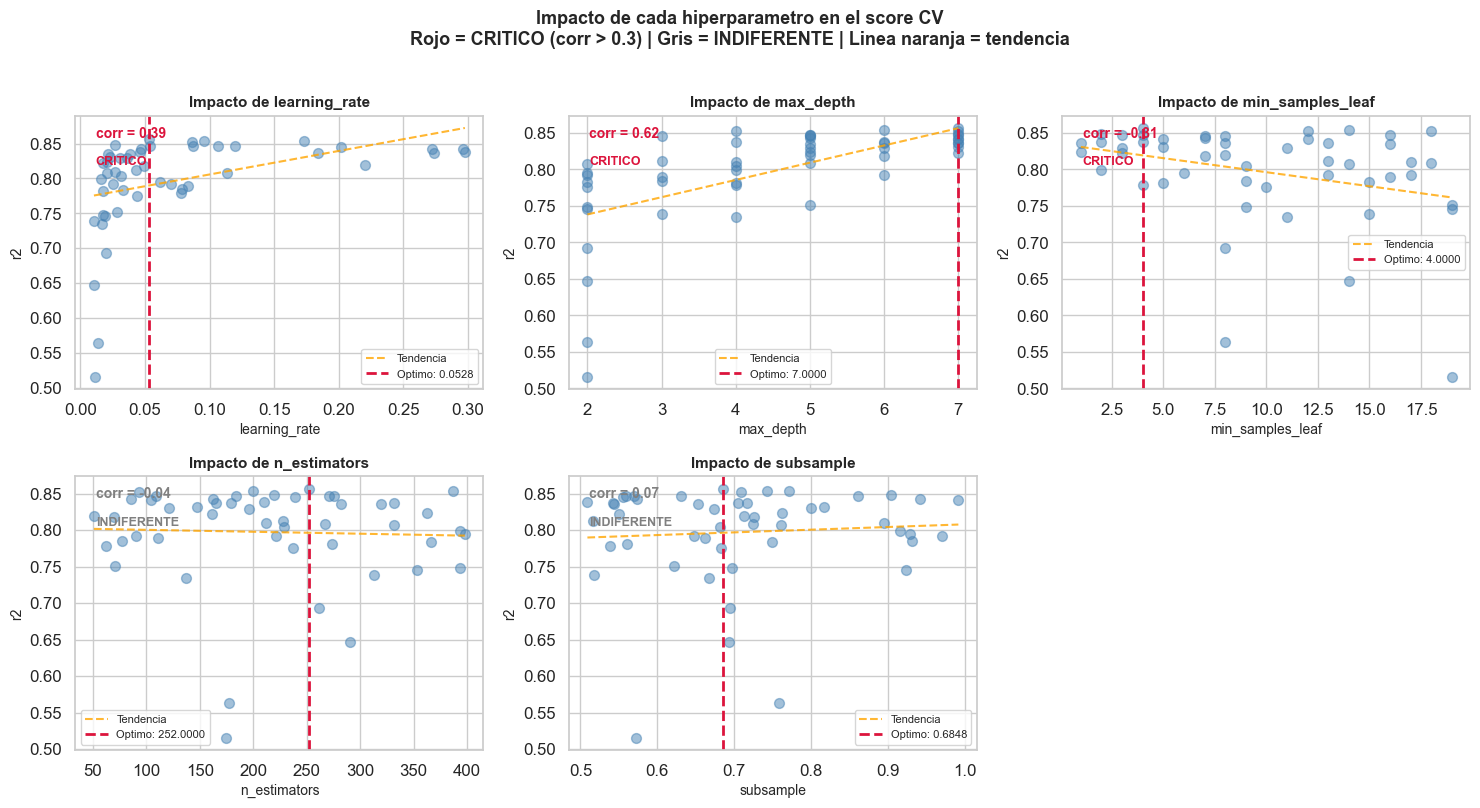

RESUMEN DE IMPACTO POR PARAMETRO:
-------------------------------------------------------
  learning_rate             corr=+0.392  CRITICO     <- incluir en GridSearch
  max_depth                 corr=+0.621  CRITICO     <- incluir en GridSearch
  min_samples_leaf          corr=-0.308  CRITICO     <- incluir en GridSearch
  n_estimators              corr=-0.039  indiferente <- omitir del GridSearch
  subsample                 corr=+0.072  indiferente <- omitir del GridSearch


In [11]:
# ── 5c. Visualizar el impacto de cada hiperparametro ─────────────────────────

params_candidatos = [
    c for c in df_resultados_random.columns
    if c.startswith('param_modelo__')
]

# Convertir a numerico forzando errores a NaN
# (las columnas de cv_results_ son dtype object aunque contengan numeros)
params_num = []
for c in params_candidatos:
    serie_num = pd.to_numeric(df_resultados_random[c], errors='coerce')
    valores_validos = serie_num.dropna()
    if len(valores_validos) > 3 and valores_validos.nunique() > 3:
        df_resultados_random[c + '_num'] = serie_num
        params_num.append(c + '_num')

if params_num:
    ncols = min(3, len(params_num))
    nrows = (len(params_num) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = np.array(axes).flatten()

    for i, param in enumerate(params_num):
        nombre_corto = param.replace('param_modelo__', '').replace('_num', '')

        # Filtrar filas donde el parametro tiene valor numerico valido
        mask = df_resultados_random[param].notna()
        x = df_resultados_random.loc[mask, param]
        y = df_resultados_random.loc[mask, 'mean_test_score']

        axes[i].scatter(x, y, alpha=0.5, color='steelblue', s=50)

        # Linea de tendencia
        try:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            x_line = np.linspace(x.min(), x.max(), 100)
            axes[i].plot(x_line, p(x_line), color='orange',
                         lw=1.5, ls='--', alpha=0.8, label='Tendencia')
        except Exception:
            pass

        # Marcar el valor optimo encontrado
        mejor_val = random_search.best_params_.get(f'modelo__{nombre_corto}')
        if mejor_val is not None:
            try:
                mejor_val_num = float(mejor_val)
                axes[i].axvline(
                    mejor_val_num, color='crimson', ls='--', lw=2,
                    label=f'Optimo: {mejor_val_num:.4f}'
                )
            except (ValueError, TypeError):
                pass

        # Calcular correlacion para saber si el parametro importa
        try:
            corr = float(np.corrcoef(x, y)[0, 1])
            color_corr = 'crimson' if abs(corr) > 0.3 else 'gray'
            axes[i].annotate(
                f'corr = {corr:.2f}',
                xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=10, color=color_corr, fontweight='bold'
            )
            if abs(corr) > 0.3:
                diagnostico = 'CRITICO'
                color_diag = 'crimson'
            else:
                diagnostico = 'INDIFERENTE'
                color_diag = 'gray'
            axes[i].annotate(
                diagnostico,
                xy=(0.05, 0.82), xycoords='axes fraction',
                fontsize=9, color=color_diag, fontweight='bold'
            )
        except Exception:
            pass

        axes[i].set_xlabel(nombre_corto, fontsize=10)
        axes[i].set_ylabel(scoring_principal, fontsize=10)
        axes[i].set_title(f'Impacto de {nombre_corto}', fontweight='bold', fontsize=11)
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        'Impacto de cada hiperparametro en el score CV\n'
        'Rojo = CRITICO (corr > 0.3) | Gris = INDIFERENTE | Linea naranja = tendencia',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    # Resumen textual
    print('RESUMEN DE IMPACTO POR PARAMETRO:')
    print('-' * 55)
    for param in params_num:
        nombre_corto = param.replace('param_modelo__', '').replace('_num', '')
        mask = df_resultados_random[param].notna()
        x = df_resultados_random.loc[mask, param]
        y = df_resultados_random.loc[mask, 'mean_test_score']
        try:
            corr = float(np.corrcoef(x, y)[0, 1])
            icono = 'CRITICO     <- incluir en GridSearch' if abs(corr) > 0.3 else 'indiferente <- omitir del GridSearch'
            print(f'  {nombre_corto:<25} corr={corr:+.3f}  {icono}')
        except Exception:
            print(f'  {nombre_corto:<25} no se pudo calcular correlacion')
else:
    print('Todos los hiperparametros explorados son categoricos.')
    print('El grafico de scatter no aplica para valores categoricos.')
    print('Revisa el top 10 del bloque anterior para identificar los valores optimos.')

---
## Paso 6 — GridSearchCV (busqueda fina, opcional)

### ¿Cuando ejecutar este paso y cuando saltarlo?

Este paso es opcional. Usa esta regla:

| Resultado del RandomizedSearch | ¿Ejecutar GridSearch? |
|---|---|
| Mejora > 0.02 sobre el base | Si — vale la pena afinar mas |
| Mejora entre 0.005 y 0.02 | Opcional — depende del tiempo disponible |
| Mejora < 0.005 | No — el modelo ya llego a su limite |

### ¿Como funciona la estrategia de dos fases?

```
RandomizedSearch encontro:
   n_estimators ~ 210  (exploro valores entre 50 y 500)
   max_depth    ~ 15   (exploro valores entre 3 y 30)

GridSearch busca exhaustivamente en la zona:
   n_estimators : [180, 200, 210, 220, 250]   <- rango estrecho alrededor de 210
   max_depth    : [12, 13, 14, 15, 16, 17]    <- rango estrecho alrededor de 15

Total combinaciones: 5 x 6 = 30  (manejable en pocos minutos)
```

---


In [12]:
# ── Que parametros aparecen consistentemente en el top 10 ────────────────────
print()
print('QUE PARAMETROS BUSCAR EN EL GRIDSEARCH (Paso 6):')
cols_param_top = [c for c in top10.columns
                  if c not in [col_cv, 'std_CV', f'{scoring_principal}_TRAIN',
                               'rank_test_score', 'tiempo_s', 'gap_overfit']
                  and top10[c].dtype in ['float64', 'int64', 'object']]
for col in cols_param_top:
    try:
        vals_unicos = top10[col].dropna().unique()
        rango = f'[{top10[col].min():.3f} - {top10[col].max():.3f}]' if top10[col].dtype in ['float64'] else str(sorted(vals_unicos)[:5])
        print(f'  {col:<25}: valores en top10 = {rango}')
        print(f'  {"":<25}  -> usa este rango como base para el GridSearch')
    except Exception:
        pass


QUE PARAMETROS BUSCAR EN EL GRIDSEARCH (Paso 6):
  learning_rate            : valores en top10 = [0.027 - 0.202]
                             -> usa este rango como base para el GridSearch
  max_depth                : valores en top10 = [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
                             -> usa este rango como base para el GridSearch
  min_samples_leaf         : valores en top10 = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8)]
                             -> usa este rango como base para el GridSearch
  n_estimators             : valores en top10 = [np.int64(93), np.int64(109), np.int64(184), np.int64(200), np.int64(219)]
                             -> usa este rango como base para el GridSearch
  subsample                : valores en top10 = [0.555 - 0.904]
                             -> usa este rango como base para el GridSearch


In [13]:
# Resumen textual
try:
    print('RESUMEN DE IMPACTO POR PARAMETRO:')
    print('-' * 55)
    for param in params_num:

        nombre_corto = param.replace('param_modelo__', '').replace('_num', '')
        mask = df_resultados_random[param].notna()
        x = df_resultados_random.loc[mask, param]
        y = df_resultados_random.loc[mask, 'mean_test_score']
        try:
            corr = float(np.corrcoef(x, y)[0, 1])
            icono = 'CRITICO     <- incluir en GridSearch' if abs(corr) > 0.3 else 'indiferente <- omitir del GridSearch'
            print(f'  {nombre_corto:<25} corr={corr:+.3f}  {icono}')
        except Exception:
            print(f'  {nombre_corto:<25} no se pudo calcular correlacion')
except Exception:
    print('No se pudieron analizar los parametros numericos. Revisa el top 10 para identificar los valores optimos.')
    


RESUMEN DE IMPACTO POR PARAMETRO:
-------------------------------------------------------
  learning_rate             corr=+0.392  CRITICO     <- incluir en GridSearch
  max_depth                 corr=+0.621  CRITICO     <- incluir en GridSearch
  min_samples_leaf          corr=-0.308  CRITICO     <- incluir en GridSearch
  n_estimators              corr=-0.039  indiferente <- omitir del GridSearch
  subsample                 corr=+0.072  indiferente <- omitir del GridSearch


In [14]:
# DECISION POINT ── 5d. Definir el espacio de busqueda para GridSearchCV (afinamiento) ─────────────
# ═══════════════════════════════════════════════════════════════════════════
decision_point = "ACTIVADO" #<-- CAMBIA a "ACTIVADO" para ejecutar el GridSearch de afinamiento ELSE "DESACTIVADO" para omitirlo


param_grid_codificados_manualmente = {
    'modelo__learning_rate': [0.02, 0.05, 0.1, 0.15, 0.2, 0.25],   # <-- ajusta
    'modelo__max_depth': [2, 3, 4, 5, 6, 7, 8],           # <-- ajusta
    'modelo__min_samples_leaf': [2, 3, 4, 5, 6, 8],                    # <-- ajusta
}

if decision_point == "ACTIVADO":
    param_grid_mapeados = param_grid_codificados_manualmente
    print(f'Espacio de busqueda definido para GridSearchCV (afinamiento)')
else: 
    param_grid_mapeados = None
    print(f'Espacio de busqueda ESTÁ VACÍO. El GridSearch de afinamiento será omitido.')

Espacio de busqueda definido para GridSearchCV (afinamiento)


In [15]:
# ── 6a. Parametrizando espacio FINO para GridSearch ──────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Define un espacio de busqueda estrecho alrededor de los mejores
#   valores encontrados por RandomizedSearch. GridSearch prueba TODAS
#   las combinaciones de este espacio reducido.
#
# POR QUE ES IMPORTANTE
#   RandomizedSearch encuentra la zona del optimo pero no necesariamente
#   el valor exacto. GridSearch en un espacio pequeno garantiza encontrar
#   la mejor combinacion dentro de ese rango.
#
# QUE DEBEMOS ESPERAR
#   El espacio fino debe tener maximo 3-5 valores por parametro.
#   Con 3 parametros de 3 valores cada uno: 27 combinaciones (rapido).
#   El score debe ser igual o ligeramente mejor que el RandomizedSearch.
# ═══════════════════════════════════════════════════════════════════════════

# Lee los mejores valores del RandomizedSearch y construye rangos estrechos
mejores_params = random_search.best_params_
print('Mejores valores del RandomizedSearch (punto de partida para el Grid):')
for k, v in mejores_params.items():
    print(f'   {k.replace("modelo__", ""):<30} : {v}')

print()

if param_grid_mapeados is not None:
    param_grid_fino = param_grid_mapeados
else:
    param_grid_fino = None

if param_grid_fino is not None:
    # Calcular cuantas combinaciones tiene el grid
    n_combinaciones = 1
    for vals in param_grid_fino.values():
        n_combinaciones *= len(vals)
    n_fits = n_combinaciones * 5

    print(f'\nEspacio fino definido:')
    print(f'   Combinaciones : {n_combinaciones}')
    print(f'   Total fits    : {n_fits} (combinaciones x 5 folds)')
    print()
    if n_combinaciones > 200:
        print('AVISO: el grid tiene mas de 200 combinaciones. Puede tardar mucho.')
        print('Considera reducir el numero de valores por parametro.')
else:
    print('El espacio de busqueda para el GridSearch esta vacio.')
    print('El afinamiento con GridSearch sera omitido.')


Mejores valores del RandomizedSearch (punto de partida para el Grid):
   learning_rate                  : 0.052842222499425995
   max_depth                      : 7
   max_features                   : 0.7
   min_samples_leaf               : 4
   n_estimators                   : 252
   subsample                      : 0.6848272280307022


Espacio fino definido:
   Combinaciones : 252
   Total fits    : 1260 (combinaciones x 5 folds)

AVISO: el grid tiene mas de 200 combinaciones. Puede tardar mucho.
Considera reducir el numero de valores por parametro.


### DECISION POINT — ¿Ejecuto el GridSearch o no?

Para ejecutar el GridSearch, descomenta TODO el bloque (selecciona el codigo
y quita los `#` del inicio de cada linea).

**¿Cuando ejecutarlo?**
Si la mejora del RandomizedSearch fue mayor a 0.01 en el score de CV.
Ejemplo: si el base era 0.82 y RandomizedSearch encontro 0.87, ejecutalo.

**¿Cuando NO ejecutarlo?**
Si la mejora fue menor a 0.005. En ese caso el modelo ya esta cerca de su
limite con los datos actuales. Mas busqueda no va a cambiar eso.

**¿Que pasa despues de ejecutarlo?**
En el Paso 7 cambia esta linea para usar el resultado del GridSearch:
```python
# En el Paso 7, cambia:
pipeline_opt = random_search.best_estimator_

# Por:
pipeline_opt = grid_search.best_estimator_
```


In [53]:
# DECISION POINT ── 6b. Ejecutar GridSearchCV fino ───────────────────────────
# DECISION POINT: descomenta si quieres ejecutar el GridSearch fino.
# Si la mejora del RandomizedSearch fue < 0.01, puedes saltar al Paso 7.

grid_search = GridSearchCV(
    estimator  = pipeline_base,
    param_grid = param_grid_fino,
    cv         = cv,
    scoring    = scoring_principal,
    refit      = True,
    n_jobs     = -1,
    verbose    = 1,
    return_train_score = True,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
t_grid = round(time.time() - t0, 2)

print(f'GridSearchCV completado en {t_grid}s')
print(f'Mejor score CV (Grid) : {grid_search.best_score_:.4f}')
print(f'Mejor score CV (Rand) : {random_search.best_score_:.4f}')
print(f'Mejora adicional       : {grid_search.best_score_ - random_search.best_score_:+.4f}')
print(f'\nMejores hiperparametros (GridSearch):')
for param, valor in grid_search.best_params_.items():
    print(f'   {param.replace("modelo__", ""):<30} : {valor}')



Fitting 5 folds for each of 210 candidates, totalling 1050 fits
GridSearchCV completado en 431.11s
Mejor score CV (Grid) : 0.8495
Mejor score CV (Rand) : 0.8552
Mejora adicional       : -0.0057

Mejores hiperparametros (GridSearch):
   learning_rate                  : 0.09
   max_depth                      : 7
   min_samples_leaf               : 5


---
## Paso 7 — Comparar modelo base vs modelo optimizado

### El momento de la verdad

El tuning solo tiene valor si podemos demostrar que mejoro el modelo.
Aqui comparamos las metricas completas (CV + test) antes y despues.

### ¿Que significan los tres posibles resultados?

**Resultado 1 — Mejora significativa (> 0.02):**
```
Base      : ROC-AUC = 0.82
Optimizado: ROC-AUC = 0.89
Mejora    : +0.07  <- el tuning fue muy exitoso
```
Accion: usa el pipeline optimizado. Considera ejecutar el GridSearch del Paso 6 para afinar mas.

**Resultado 2 — Mejora marginal (0 a 0.02):**
```
Base      : ROC-AUC = 0.85
Optimizado: ROC-AUC = 0.86
Mejora    : +0.01  <- mejora pero pequena
```
Accion: puedes usar cualquiera de los dos. El optimizado es ligeramente mejor.

**Resultado 3 — Sin mejora o empeoro:**
```
Base      : ROC-AUC = 0.85
Optimizado: ROC-AUC = 0.84
Mejora    : -0.01  <- el tuning no ayudo
```
Accion: el cuello de botella **no son los hiperparametros**. Opciones:
- a) Ampliar el espacio de busqueda y aumentar `n_iter`
- b) Volver al Feature Engineering: agregar mejores features
- c) Probar un modelo diferente en el Notebook de Comparacion

### ¿Por que verificamos tanto en CV como en test?

El score de CV es lo que el search optimizo. Pero necesitamos confirmar que
esa mejora se traslada al test real. Si CV mejoro pero test no, puede indicar
que el espacio de busqueda era demasiado especifico para el train.

---


In [16]:
# ── 7. Comparacion completa: Base vs RandomizedSearch vs GridSearch ──────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Calcula las metricas de los tres pipelines disponibles:
#   1. Base       : el modelo con hiperparametros por defecto de sklearn
#   2. Randomized : el mejor modelo encontrado por RandomizedSearchCV
#   3. Grid       : el mejor modelo encontrado por GridSearchCV (si se ejecuto)
#   Luego compara los tres y genera comentarios automaticos sobre cada mejora.
#
# POR QUE ES IMPORTANTE
#   Ver los tres juntos permite tomar una decision informada:
#   - Si Randomized ya fue suficiente, Grid no anadio valor
#   - Si Grid mejoro sobre Randomized, vale la pena el tiempo extra
#   - Si ninguno supera al Base, el cuello de botella no son los hiperparametros
#
# QUE DEBEMOS ESPERAR
#   Columnas: Base | Randomized | Grid (si existe) | Mejor de los tres
#   Las filas son las metricas clave del problema.
#   La columna 'Mejor' siempre debe apuntar a Randomized o Grid, nunca a Base.
#   Si apunta a Base, el tuning no funcionó y debes revisar el espacio de busqueda.
# ═══════════════════════════════════════════════════════════════════════════

# ── Definir cual pipeline usar como 'optimizado final' ────────────────────
# DECISION POINT: el notebook detecta automaticamente si ejecutaste GridSearch.
# Si grid_search existe en memoria, lo usa automaticamente.
# Si no existe, usa el resultado del RandomizedSearch.
pipeline_rand = random_search.best_estimator_
grid_ejecutado = 'grid_search' in dir() and grid_search is not None

if grid_ejecutado:
    pipeline_grid = grid_search.best_estimator_
    pipeline_opt  = pipeline_grid   # el mejor final es el Grid
    print('GridSearch detectado. Comparando los tres pipelines.')
else:
    pipeline_grid = None
    pipeline_opt  = pipeline_rand   # el mejor final es el Randomized
    print('GridSearch no ejecutado. Comparando Base vs RandomizedSearch.')

# ── Funcion auxiliar para calcular todas las metricas de un pipeline ─────
def calcular_metricas(pipe, nombre):
    scores_cv = cross_val_score(pipe, X_train, y_train,
                                cv=cv, scoring=scoring_principal, n_jobs=-1)
    y_pred_p  = pipe.predict(X_test)

    if TIPO_PROBLEMA == 'clasificacion':
        prob      = pipe.predict_proba(X_test)
        avg       = 'binary' if n_clases == 2 else 'macro'
        roc_t     = roc_auc_score(y_test, prob[:, 1]) if n_clases == 2 else \
                    roc_auc_score(y_test, prob, multi_class='ovr', average='macro')
        return {
            'Pipeline'      : nombre,
            'ROC-AUC (CV)'  : round(scores_cv.mean(), 4),
            'std CV'        : round(scores_cv.std(),  4),
            'ROC-AUC (test)': round(roc_t, 4),
            'F1 (test)'     : round(f1_score(y_test, y_pred_p, average=avg, zero_division=0), 4),
            'Accuracy'      : round(accuracy_score(y_test, y_pred_p), 4),
        }
    else:
        r2   = r2_score(y_test, y_pred_p)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_p))
        mae  = mean_absolute_error(y_test, y_pred_p)
        return {
            'Pipeline'  : nombre,
            'R2 (CV)'   : round(scores_cv.mean(), 4),
            'std CV'    : round(scores_cv.std(),  4),
            'R2 (test)' : round(r2,   4),
            'RMSE (test)': round(rmse, 4),
            'MAE (test)' : round(mae,  4),
        }

# ── Calcular metricas de cada pipeline ────────────────────────────────────
print('\nCalculando metricas... (puede tardar unos segundos por el CV)')
metricas_base = calcular_metricas(pipeline_base, 'Base (defaults)')
metricas_rand = calcular_metricas(pipeline_rand, 'RandomizedSearch')
metricas_grid = calcular_metricas(pipeline_grid, 'GridSearch') if grid_ejecutado else None

# ── Construir tabla comparativa ───────────────────────────────────────────
filas = [metricas_base, metricas_rand]
if metricas_grid:
    filas.append(metricas_grid)

df_comp = pd.DataFrame(filas).set_index('Pipeline')

# Identificar el mejor valor de cada metrica
col_principal = 'ROC-AUC (CV)' if TIPO_PROBLEMA == 'clasificacion' else 'R2 (CV)'
col_test      = 'ROC-AUC (test)' if TIPO_PROBLEMA == 'clasificacion' else 'R2 (test)'

# Calcular mejoras respecto al Base
for col in df_comp.columns:
    if col == 'std CV':
        continue
    base_val = df_comp.loc['Base (defaults)', col]
    for idx in df_comp.index:
        if idx != 'Base (defaults)':
            diff = df_comp.loc[idx, col] - base_val
            pct  = (diff / abs(base_val) * 100) if base_val != 0 else 0
            # No agregar columnas extra, solo mostrar en el reporte textual

print('\n=== TABLA COMPARATIVA COMPLETA ===')
print('(degradado verde = mayor es mejor | para RMSE/MAE menor es mejor)')
print()

# Aplicar gradientes segun si mayor o menor es mejor
cols_mayor_mejor = [c for c in df_comp.columns if c not in ['std CV', 'RMSE (test)', 'MAE (test)']]
cols_menor_mejor = [c for c in df_comp.columns if c in ['std CV', 'RMSE (test)', 'MAE (test)']]

estilo = df_comp.style
if cols_mayor_mejor:
    estilo = estilo.background_gradient(subset=cols_mayor_mejor, cmap='Greens')
if cols_menor_mejor:
    estilo = estilo.background_gradient(subset=cols_menor_mejor, cmap='Greens_r')
estilo = estilo.format(precision=4)
display(estilo)

# ── Reporte de mejoras respecto al Base ───────────────────────────────────
sep  = '-' * 65
sep2 = '=' * 65

print()
print(sep2)
print('  REPORTE DE MEJORAS RESPECTO AL MODELO BASE')
print(sep2)

def comentario_mejora(nombre, cv_base, cv_nuevo, test_base, test_nuevo, metrica):
    diff_cv   = cv_nuevo   - cv_base
    diff_test = test_nuevo - test_base
    pct_cv    = diff_cv   / abs(cv_base)   * 100 if cv_base   != 0 else 0
    pct_test  = diff_test / abs(test_base) * 100 if test_base != 0 else 0

    print(f'\n  [{nombre}]')
    print(f'  {metrica} (CV)   : base={cv_base:.4f}  ->  {cv_nuevo:.4f}  ({diff_cv:+.4f} | {pct_cv:+.1f}%)')
    print(f'  {metrica} (test) : base={test_base:.4f}  ->  {test_nuevo:.4f}  ({diff_test:+.4f} | {pct_test:+.1f}%)')

    # Diagnostico cruzado CV vs test
    if diff_cv > 0.02 and diff_test > 0.02:
        print(f'  RESULTADO    : EXCELENTE. Mejoro en CV y en test.')
        print(f'  RECOMENDACION: Usa este pipeline.')
    elif diff_cv > 0.005 and diff_test > 0:
        print(f'  RESULTADO    : BUENO. Mejoro en CV y ligeramente en test.')
        print(f'  RECOMENDACION: Usa este pipeline.')
    elif diff_cv > 0 and diff_test <= 0:
        print(f'  RESULTADO    : ATENCION. Mejoro en CV pero no en test.')
        print(f'  RECOMENDACION: El tuning sobreajusto al train.')
        print(f'                 Considera usar el Base o ampliar el espacio de busqueda.')
    elif diff_cv <= 0 and diff_test <= 0:
        print(f'  RESULTADO    : SIN MEJORA. El tuning no ayudo.')
        print(f'  RECOMENDACION: El cuello de botella no son los hiperparametros.')
        print(f'                 Opciones: revisar FE, probar otro modelo, aumentar n_iter.')
    else:
        print(f'  RESULTADO    : MEJORA MARGINAL.')
        print(f'  RECOMENDACION: Cualquiera de los dos pipelines es valido.')

cv_base   = metricas_base[col_principal]
test_base = metricas_base[col_test]

comentario_mejora(
    'RandomizedSearch',
    cv_base, metricas_rand[col_principal],
    test_base, metricas_rand[col_test],
    col_principal.replace(' (CV)', '')
)

if metricas_grid:
    comentario_mejora(
        'GridSearch',
        cv_base, metricas_grid[col_principal],
        test_base, metricas_grid[col_test],
        col_principal.replace(' (CV)', '')
    )

    # Comparacion adicional: GridSearch vs RandomizedSearch
    diff_grid_vs_rand = metricas_grid[col_principal] - metricas_rand[col_principal]
    print(f'\n  [GridSearch vs RandomizedSearch]')
    print(f'  Diferencia en CV: {diff_grid_vs_rand:+.4f}')
    if diff_grid_vs_rand > 0.005:
        print(f'  El GridSearch mejoro sobre el RandomizedSearch. Vale la pena el tiempo extra.')
    elif diff_grid_vs_rand >= 0:
        print(f'  El GridSearch no mejoro significativamente sobre el RandomizedSearch.')
        print(f'  El RandomizedSearch ya habia encontrado un optimo suficientemente bueno.')
    else:
        print(f'  El RandomizedSearch fue mejor que el GridSearch.')
        print(f'  Revisa el espacio fino del GridSearch: puede ser demasiado estrecho.')

# ── Cual pipeline usar para el resto del proyecto ─────────────────────────
print()
print(sep)
print('  DECISION FINAL: cual pipeline exportar al Paso 9')
print(sep)

candidatos = {'Base (defaults)': metricas_base}
candidatos['RandomizedSearch'] = metricas_rand
if metricas_grid:
    candidatos['GridSearch'] = metricas_grid

ganador = max(candidatos, key=lambda k: candidatos[k][col_principal])
print(f'  Pipeline con mejor {col_principal}: {ganador}')
print(f'  Valor: {candidatos[ganador][col_principal]:.4f}')
print()
if ganador == 'Base (defaults)':
    print('  El tuning no mejoro el modelo base.')
    print('  -> Usa pipeline_base en el Paso 8.')
    print('  -> Considera revisar el Feature Engineering o ampliar el espacio de busqueda.')
    pipeline_opt = pipeline_base
elif ganador == 'RandomizedSearch':
    print('  El RandomizedSearch fue suficiente.')
    print('  -> Usa pipeline_rand en el Paso 8.')
    pipeline_opt = pipeline_rand
else:
    print('  El GridSearch afino aun mas el resultado.')
    print('  -> Usa pipeline_grid en el Paso 8.')
    pipeline_opt = pipeline_grid

print(f'\n  pipeline_opt = {ganador} <- este se exportara en el Paso 8')
print(sep2)

GridSearch no ejecutado. Comparando Base vs RandomizedSearch.

Calculando metricas... (puede tardar unos segundos por el CV)

=== TABLA COMPARATIVA COMPLETA ===
(degradado verde = mayor es mejor | para RMSE/MAE menor es mejor)



,R2 (CV),std CV,R2 (test),RMSE (test),MAE (test)
Pipeline,,,,,
Base (defaults),0.8130,0.0091,0.8108,0.2302,0.1739
RandomizedSearch,0.8568,0.0086,0.8622,0.1964,0.1447



  REPORTE DE MEJORAS RESPECTO AL MODELO BASE

  [RandomizedSearch]
  R2 (CV)   : base=0.8130  ->  0.8568  (+0.0438 | +5.4%)
  R2 (test) : base=0.8108  ->  0.8622  (+0.0514 | +6.3%)
  RESULTADO    : EXCELENTE. Mejoro en CV y en test.
  RECOMENDACION: Usa este pipeline.

-----------------------------------------------------------------
  DECISION FINAL: cual pipeline exportar al Paso 9
-----------------------------------------------------------------
  Pipeline con mejor R2 (CV): RandomizedSearch
  Valor: 0.8568

  El RandomizedSearch fue suficiente.
  -> Usa pipeline_rand en el Paso 8.

  pipeline_opt = RandomizedSearch <- este se exportara en el Paso 8


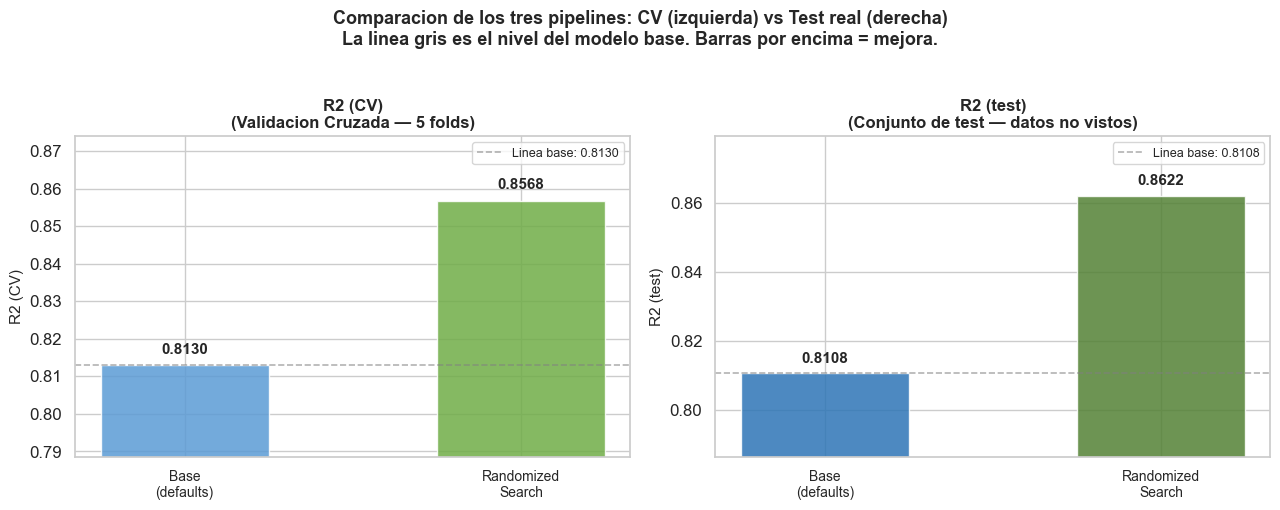

RESUMEN DE MEJORAS SOBRE EL BASE:
Pipeline                       CV         Test Diagnostico
-----------------------------------------------------------------
Randomized Search         +0.0438      +0.0514   Mejoro en ambos


In [17]:
# ── Grafico comparativo de los tres pipelines ────────────────────────────────

# Construir datos para el grafico
pipelines_nombres = ['Base\n(defaults)', 'Randomized\nSearch']
vals_cv    = [metricas_base[col_principal], metricas_rand[col_principal]]
vals_test  = [metricas_base[col_test],      metricas_rand[col_test]]

if metricas_grid:
    pipelines_nombres.append('Grid\nSearch')
    vals_cv.append(metricas_grid[col_principal])
    vals_test.append(metricas_grid[col_test])

x     = np.arange(len(pipelines_nombres))
width = 0.35
colores_cv   = ['#5b9bd5', '#70ad47', '#ed7d31'][:len(pipelines_nombres)]
colores_test = ['#2e75b6', '#538135', '#c55a11'][:len(pipelines_nombres)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Grafico 1: Score CV ────────────────────────────────────────────────────
bars_cv = axes[0].bar(x, vals_cv, width=0.5,
                      color=colores_cv, alpha=0.85, edgecolor='white')
for bar, val in zip(bars_cv, vals_cv):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(vals_cv[0], color='gray', ls='--', lw=1.2, alpha=0.6,
                label=f'Linea base: {vals_cv[0]:.4f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pipelines_nombres, fontsize=10)
axes[0].set_ylabel(col_principal, fontsize=11)
axes[0].set_title(f'{col_principal}\n(Validacion Cruzada — 5 folds)',
                   fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9)
y_min = min(vals_cv) * 0.97
y_max = max(vals_cv) * 1.02
axes[0].set_ylim(y_min, y_max)

# ── Grafico 2: Score en Test ───────────────────────────────────────────────
bars_test = axes[1].bar(x, vals_test, width=0.5,
                        color=colores_test, alpha=0.85, edgecolor='white')
for bar, val in zip(bars_test, vals_test):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(vals_test[0], color='gray', ls='--', lw=1.2, alpha=0.6,
                label=f'Linea base: {vals_test[0]:.4f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels(pipelines_nombres, fontsize=10)
axes[1].set_ylabel(col_test, fontsize=11)
axes[1].set_title(f'{col_test}\n(Conjunto de test — datos no vistos)',
                   fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)
y_min2 = min(vals_test) * 0.97
y_max2 = max(vals_test) * 1.02
axes[1].set_ylim(y_min2, y_max2)

fig.suptitle(
    'Comparacion de los tres pipelines: CV (izquierda) vs Test real (derecha)\n'
    'La linea gris es el nivel del modelo base. Barras por encima = mejora.',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Resumen visual de mejoras ─────────────────────────────────────────────
print('RESUMEN DE MEJORAS SOBRE EL BASE:')
print(f'{"Pipeline":<20} {"CV":>12} {"Test":>12} {"Diagnostico"}')
print('-' * 65)
for nombre, vals_cv_p, vals_test_p in zip(
    pipelines_nombres[1:],
    vals_cv[1:],
    vals_test[1:]
):
    d_cv   = vals_cv_p   - vals_cv[0]
    d_test = vals_test_p - vals_test[0]
    nombre_limpio = nombre.replace('\n', ' ')
    if d_cv > 0 and d_test > 0:
        diag = 'Mejoro en ambos'
    elif d_cv > 0 and d_test <= 0:
        diag = 'Solo mejoro en CV (atencion)'
    elif d_cv <= 0 and d_test > 0:
        diag = 'Solo mejoro en test (inusual)'
    else:
        diag = 'Sin mejora'
    print(f'{nombre_limpio:<20} {d_cv:>+12.4f} {d_test:>+12.4f}   {diag}')


---
## Paso 8 — Resumen del Hyperparameter Tuning

---


In [18]:
# ── Resumen del Hyperparameter Tuning ────────────────────────────────────────

sep  = '-' * 70
sep2 = '=' * 70

print(sep2)
print('  RESUMEN DE HYPERPARAMETER TUNING')
print(f'  Modelo    : {nombre_modelo}')
print(f'  Problema  : {TIPO_PROBLEMA}')
print(f'  Scoring   : {scoring_principal}')
print(sep2)

# ── 1. RESULTADOS DE LA BUSQUEDA ─────────────────────────────────────────────
print(f'\n1. RESULTADOS DE LA BUSQUEDA')
print(sep)
print(f'   Iteraciones RandomizedSearch : {N_ITER}')
print(f'   Score base (CV)              : {score_base_mean:.4f} +/- {score_base_std:.4f}')
print(f'   Score RandomizedSearch (CV)  : {metricas_rand[col_principal]:.4f}')
print(f'   Mejora vs base               : {metricas_rand[col_principal] - score_base_mean:+.4f}')
print(f'   Tiempo RandomizedSearch      : {t_random}s')

if grid_ejecutado:
    print(f'   Score GridSearch (CV)        : {metricas_grid[col_principal]:.4f}')
    print(f'   Mejora GridSearch vs base    : {metricas_grid[col_principal] - score_base_mean:+.4f}')
    print(f'   Mejora GridSearch vs Random  : {metricas_grid[col_principal] - metricas_rand[col_principal]:+.4f}')

# ── 2. MEJORES HIPERPARAMETROS ────────────────────────────────────────────────
print(f'\n2. MEJORES HIPERPARAMETROS')
print(sep)

# Obtener defaults del modelo base para comparar
params_modelo_local = {
    k.replace('modelo__', ''): v
    for k, v in pipeline_base.get_params().items()
    if k.startswith('modelo__') and '__' not in k.replace('modelo__', '')
}

# Fuente de los mejores params: GridSearch si se ejecuto, sino RandomizedSearch
fuente_params = 'GridSearch' if grid_ejecutado else 'RandomizedSearch'
mejores_params_final = (
    grid_search.best_params_ if grid_ejecutado
    else random_search.best_params_
)

print(f'   Fuente: {fuente_params}')
print(f'   {"Parametro":<30} {"Valor optimo":>20}   {"Default":>15}   Cambio')
print(f'   {"-"*30} {"-"*20}   {"-"*15}   {"-"*25}')
for param, valor in mejores_params_final.items():
    nombre_corto = param.replace('modelo__', '')
    default_val  = params_modelo_local.get(nombre_corto, 'N/A')
    val_str      = f'{valor:.6f}' if isinstance(valor, float) else str(valor)
    cambio       = f'CAMBIO  (era {default_val})' if str(valor) != str(default_val) else 'igual al default'
    print(f'   {nombre_corto:<30} {val_str:>20}   {str(default_val):>15}   {cambio}')

# ── 3. COMPARACION COMPLETA ───────────────────────────────────────────────────
print(f'\n3. COMPARACION BASE vs RESULTADOS')
print(sep)
for pipeline_nombre in df_comp.index:
    if pipeline_nombre == 'Base (defaults)':
        continue
    print(f'\n   [{pipeline_nombre}]')
    for col in df_comp.columns:
        if col == 'std CV':
            continue
        val_base = df_comp.loc['Base (defaults)', col]
        val_opt  = df_comp.loc[pipeline_nombre, col]
        diff     = val_opt - val_base
        if col in ['RMSE (test)', 'MAE (test)']:
            icono = 'MEJORO' if diff <= 0 else 'EMPEORO'
        else:
            icono = 'MEJORO' if diff >= 0 else 'EMPEORO'
        print(f'   {icono}  {col:<20} base={val_base:.4f}  nuevo={val_opt:.4f}  ({diff:+.4f})')

# ── 4. PIPELINE GANADOR ───────────────────────────────────────────────────────
print(f'\n4. PIPELINE GANADOR')
print(sep)
print(f'   Pipeline exportado al Paso 8 : {ganador}')
print(f'   Score CV del ganador         : {df_comp.loc[ganador, col_principal]:.4f}')
print(f'   Score test del ganador       : {df_comp.loc[ganador, col_test]:.4f}')
print(f'   Mejora total vs base (CV)    : {df_comp.loc[ganador, col_principal] - score_base_mean:+.4f}')

# ── 5. CHECKLIST DE TUNING ────────────────────────────────────────────────────
print(f'\n5. CHECKLIST DE TUNING')
print(sep)
checklist = [
    ('Metricas base calculadas',             True),
    ('Espacio de busqueda definido',         True),
    ('RandomizedSearchCV ejecutado',         True),
    ('Impacto de hiperparametros analizado', True),
    ('GridSearchCV ejecutado',               grid_ejecutado),
    ('Comparacion de pipelines completada',  True),
    ('Pipeline ganador exportado (.pkl)',    True),
]
for nombre_c, estado in checklist:
    icono = 'OK' if estado else 'PENDIENTE'
    print(f'   [{icono}]  {nombre_c}')

# ── 6. PROXIMOS PASOS ─────────────────────────────────────────────────────────
print(f'\n6. PROXIMOS PASOS')
print(sep)
print('   -> Continua en el Notebook de Evaluacion (numerado como 6)')
print('      El pipeline_modelo.pkl ya fue reemplazado por el ganador.')
print('      La Evaluacion usara automaticamente el modelo tuneado.')

mejora_final = df_comp.loc[ganador, col_principal] - score_base_mean
if mejora_final > 0.02:
    print('\n   TIP: la mejora fue significativa (>0.02). El tuning fue exitoso.')
    if not grid_ejecutado:
        print('        Si quieres afinar aun mas, ejecuta el GridSearch del Paso 6.')
elif mejora_final > 0:
    print('\n   TIP: mejora marginal. El modelo ya estaba bien ajustado con los defaults.')
else:
    print('\n   TIP: el tuning no mejoro el modelo. Opciones:')
    print('        a) Ampliar el espacio de busqueda (rangos mas amplios en Paso 4)')
    print('        b) Aumentar n_iter en el Paso 5 (mas combinaciones exploradas)')
    print('        c) Volver al FE: el cuello de botella no son los hiperparametros')
    print('        d) Probar otro modelo en el Notebook de Comparacion')

print()
print(sep2)
print('  Hyperparameter Tuning completado.')
print(sep2)

  RESUMEN DE HYPERPARAMETER TUNING
  Modelo    : GradientBoostingRegressor
  Problema  : regresion
  Scoring   : r2

1. RESULTADOS DE LA BUSQUEDA
----------------------------------------------------------------------
   Iteraciones RandomizedSearch : 50
   Score base (CV)              : 0.8130 +/- 0.0091
   Score RandomizedSearch (CV)  : 0.8568
   Mejora vs base               : +0.0438
   Tiempo RandomizedSearch      : 77.79s

2. MEJORES HIPERPARAMETROS
----------------------------------------------------------------------
   Fuente: RandomizedSearch
   Parametro                              Valor optimo           Default   Cambio
   ------------------------------ --------------------   ---------------   -------------------------
   learning_rate                              0.052842               0.1   CAMBIO  (era 0.1)
   max_depth                                         7                 3   CAMBIO  (era 3)
   max_features                               0.700000              None   C

---
## Paso 9 — Exportar el pipeline optimizado

### ¿Que hace este paso?

Guarda el pipeline optimizado en el mismo archivo `pipeline_modelo.pkl`
que creo el Notebook de Modelado. Al sobrescribir ese archivo, el
Notebook de Evaluacion (6) cargara automaticamente el modelo tuneado
sin que tengas que cambiar nada en ese notebook.

### ¿Que contiene el archivo .pkl?

```
pipeline_modelo.pkl
├── preprocesamiento (ColumnTransformer)
│   ├── pipeline numericas (SimpleImputer + RobustScaler)
│   ├── pipeline categoricas (SimpleImputer + OneHotEncoder)
│   └── pipeline fechas (FunctionTransformer + StandardScaler)
└── modelo (RandomForestClassifier con los MEJORES hiperparametros)
    ├── n_estimators = 210   <- el valor encontrado por el tuning
    ├── max_depth = 15       <- el valor encontrado por el tuning
    └── ...                  <- todos los demas hiperparametros
```

> **Este es el objeto que se despliega en produccion.**
> Cualquier equipo puede cargarlo y predecir sin reentrenar.

---


In [19]:
# pipeline escogido para exportar al Paso 8 (evaluacion final)
print(f'\nPipeline optimizado final para exportar al Paso 8: {ganador}')


Pipeline optimizado final para exportar al Paso 8: RandomizedSearch


In [20]:
# DECISION POINT ── 9. ¿Cambiar el pipeline final? ─────────────────
# si no quieres exportar el pipeline ganador, cambia el nombre aqui
# opciones para pipeline_final: pipeline_base | pipeline_rand | pipeline_grid
pipeline_final = pipeline_opt

In [21]:
# DECISION POINT ── 9. Exportar el pipeline optimizado ───────────────────────────────────────

os.makedirs('output_lineal', exist_ok=True)

# Guardar el pipeline optimizado (reemplaza al pipeline base)
joblib.dump(pipeline_final, 'output_lineal/pipeline_modelo.pkl')
print('Pipeline optimizado exportado: output_lineal/pipeline_modelo.pkl')
print(f'Tamano del archivo: {os.path.getsize("output_lineal/pipeline_modelo.pkl") / 1024:.1f} KB')

# Guardar tambien una copia con nombre descriptivo
nombre_archivo_opt = f'output_lineal/pipeline_{nombre_modelo}_tuned.pkl'
joblib.dump(pipeline_final, nombre_archivo_opt)
print(f'Copia guardada   : {nombre_archivo_opt}')

# Verificacion
pipeline_verificacion = joblib.load('output_lineal/pipeline_modelo.pkl')
y_check = pipeline_verificacion.predict(X_test[:5])
print(f'\nVerificacion (5 predicciones del pipeline cargado):')
print(y_check)
print('\nPara usar en produccion:')
print('   pipeline = joblib.load("output_lineal/pipeline_modelo.pkl")')
print('   predicciones = pipeline.predict(nuevos_datos)')

Pipeline optimizado exportado: output_lineal/pipeline_modelo.pkl
Tamano del archivo: 3065.9 KB
Copia guardada   : output_lineal/pipeline_GradientBoostingRegressor_tuned.pkl

Verificacion (5 predicciones del pipeline cargado):
[13.02798546 13.48839741 13.89230002 13.17019942 14.00120068]

Para usar en produccion:
   pipeline = joblib.load("output_lineal/pipeline_modelo.pkl")
   predicciones = pipeline.predict(nuevos_datos)
